In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset
import os
import random
from PIL import Image
import torch.nn as nn
from torchvision import models
import torch.nn.functional as F
from torch.utils.data import Dataset
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import normalize
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
random.seed(42)
torch.manual_seed(42)

# Define known and unknown classes
known_classes = ['000', '001', '002', '003', '004', '005', '006', '007', '011', '012']
unknown_classes = ['008', '009', '010']

# Define transform
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

data_dir = 'Dataset1/images'
dataset = datasets.ImageFolder(root=data_dir, transform=transform)
class_names = dataset.classes
print("All Classes:", class_names)

# Map class names to indices
class_to_idx = dataset.class_to_idx
known_indices = [class_to_idx[c] for c in known_classes]
unknown_indices = [class_to_idx[c] for c in unknown_classes]

# Split dataset into known and unknown subsets
known_idxs = [i for i, (_, label) in enumerate(dataset.samples) if label in known_indices]
unknown_idxs = [i for i, (_, label) in enumerate(dataset.samples) if label in unknown_indices]

# Subsets for known and unknown
known_dataset = Subset(dataset, known_idxs)
unknown_dataset = Subset(dataset, unknown_idxs)

# Split known dataset into train/val/test
total_len = len(known_dataset)
train_len = int(0.7 * total_len)
val_len = int(0.15 * total_len)
test_len = total_len - train_len - val_len
train_data, val_data, test_data = random_split(known_dataset, [train_len, val_len, test_len])

# DataLoaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)
unknown_loader = DataLoader(unknown_dataset, batch_size=32)

# Helper: get class names for known indices
known_class_names = [class_names[i] for i in known_indices]
unknown_class_names = [class_names[i] for i in unknown_indices]
print("Known Classes:", known_class_names)
print("Unknown Classes:", unknown_class_names)

# Model and Loss
class EfficientNet(nn.Module):
    def __init__(self, embedding_dim=512):
        super(EfficientNet, self).__init__()
        self.base_model = models.efficientnet_b0(pretrained=True)
        in_features = self.base_model.classifier[1].in_features
        self.base_model.classifier[1] = nn.Linear(in_features, embedding_dim)
    def forward(self, x):
        return self.base_model(x)

class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(TripletLoss, self).__init__()
        self.margin = margin
    def forward(self, anchor, positive, negative):
        pos_dist = F.pairwise_distance(anchor, positive)
        neg_dist = F.pairwise_distance(anchor, negative)
        loss = torch.relu(pos_dist - neg_dist + self.margin)
        return loss.mean()

class TripletDataset(Dataset):
    def __init__(self, imagefolder_dataset, indices):
        self.dataset = imagefolder_dataset
        self.indices = indices
        # Build a dict of {class_idx: list of image indices}
        self.class_to_indices = {}
        for idx in self.indices:
            _, label = self.dataset.samples[idx]
            self.class_to_indices.setdefault(label, []).append(idx)

    def __getitem__(self, index):
        anchor_idx = self.indices[index]
        anchor_img, anchor_label = self.dataset[anchor_idx]

        # Select a positive example (same class)
        positive_idx = anchor_idx
        while positive_idx == anchor_idx:
            positive_idx = random.choice(self.class_to_indices[anchor_label])
        positive_img, _ = self.dataset[positive_idx]

        # Select a negative example (different class)
        negative_label = anchor_label
        while negative_label == anchor_label:
            negative_label = random.choice(list(self.class_to_indices.keys()))
        negative_idx = random.choice(self.class_to_indices[negative_label])
        negative_img, _ = self.dataset[negative_idx]

        return anchor_img, positive_img, negative_img

    def __len__(self):
        return len(self.indices)

# Triplet datasets/loaders
triplet_train_dataset = TripletDataset(dataset, train_data.indices)
triplet_val_dataset = TripletDataset(dataset, val_data.indices)
triplet_train_loader = DataLoader(triplet_train_dataset, batch_size=32, shuffle=True)
triplet_val_loader = DataLoader(triplet_val_dataset, batch_size=32)

# Training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EfficientNet(embedding_dim=512).to(device)
criterion = TripletLoss(margin=1.0)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scaler = GradScaler()


All Classes: ['000', '001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012']
Known Classes: ['000', '001', '002', '003', '004', '005', '006', '007', '011', '012']
Unknown Classes: ['008', '009', '010']


In [2]:

epochs = 20
best_val_loss = float('inf')
patience = 3
trigger_times = 0

for epoch in range(epochs):
    model.train()
    total_loss = 0
    print(f'\nEpoch {epoch+1}/{epochs} has started -->\n')
    for anchor, positive, negative in tqdm(triplet_train_loader):
        anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)
        with autocast():
            anchor_out = model(anchor)
            positive_out = model(positive)
            negative_out = model(negative)
            loss = criterion(anchor_out, positive_out, negative_out)
        total_loss += loss.detach().item()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
    avg_train_loss = total_loss / len(triplet_train_loader)
    # Validation loss
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for anchor, positive, negative in triplet_val_loader:
            anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)
            anchor_out = model(anchor)
            positive_out = model(positive)
            negative_out = model(negative)
            loss = criterion(anchor_out, positive_out, negative_out)
            val_loss += loss.item()
    avg_val_loss = val_loss / len(triplet_val_loader)
    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_model_known_efficientnet.pth")
        print("✅ Best model saved in best_model_known_efficientnet.pth.")
        trigger_times = 0
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print("⏹️ Early stopping triggered.")
            break

# Load best model
model = EfficientNet(embedding_dim=512)
model.load_state_dict(torch.load("best_model_known_efficientnet.pth", map_location=device))
model = model.to(device)
model.eval()

# Helper: get embeddings and labels from a loader
def get_embeddings_and_labels(loader, model, device):
    all_embeddings = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            embeddings = model(images)
            all_embeddings.append(embeddings.cpu())
            all_labels.append(labels)
    return torch.cat(all_embeddings), torch.cat(all_labels)

# Get train/test embeddings for known classes
train_embeddings, train_labels = get_embeddings_and_labels(train_loader, model, device)
test_embeddings, test_labels = get_embeddings_and_labels(test_loader, model, device)

print(f"\n🔹 Train embeddings shape: {train_embeddings.shape}")
print(f"🔹 Test embeddings shape: {test_embeddings.shape}")



Epoch 1/20 has started -->



100%|██████████| 44/44 [00:15<00:00,  2.76it/s]


Epoch [1/20] - Train Loss: 0.8291, Val Loss: 0.6882
✅ Best model saved in best_model_known_efficientnet.pth.

Epoch 2/20 has started -->



100%|██████████| 44/44 [00:15<00:00,  2.93it/s]


Epoch [2/20] - Train Loss: 0.5122, Val Loss: 0.3744
✅ Best model saved in best_model_known_efficientnet.pth.

Epoch 3/20 has started -->



...

Epoch [10/20] - Train Loss: 0.0327, Val Loss: 0.0570

Epoch 11/20 has started -->



100%|██████████| 44/44 [00:15<00:00,  2.92it/s]


Epoch [11/20] - Train Loss: 0.0358, Val Loss: 0.0378

Epoch 12/20 has started -->



100%|██████████| 44/44 [00:17<00:00,  2.49it/s]


Epoch [12/20] - Train Loss: 0.0485, Val Loss: 0.0469
⏹️ Early stopping triggered.

🔹 Train embeddings shape: torch.Size([1400, 512])
🔹 Test embeddings shape: torch.Size([300, 512])


In [3]:

# Classifiers config
train_embeddings_cos = normalize(train_embeddings.numpy(), axis=1)
test_embeddings_cos = normalize(test_embeddings.numpy(), axis=1)
train_embeddings_euc = train_embeddings.numpy()
test_embeddings_euc = test_embeddings.numpy()

classifiers = {
    "KNN-Euclidean": KNeighborsClassifier(n_neighbors=5, metric="euclidean"),
    "KNN-Cosine": KNeighborsClassifier(n_neighbors=5, metric="cosine"),
    "Logistic-Euclidean": LogisticRegression(max_iter=1000),
    "Logistic-Cosine": LogisticRegression(max_iter=1000),
    "SVM-Euclidean": SVC(kernel="linear"),
    "SVM-Cosine": SVC(kernel="linear"),
}

os.makedirs("results", exist_ok=True)

for name, clf in classifiers.items():
    print(f"\n🔸 {name} Results:")
    if "Cosine" in name:
        clf.fit(train_embeddings_cos, train_labels)
        preds = clf.predict(test_embeddings_cos)
    else:
        clf.fit(train_embeddings_euc, train_labels)
        preds = clf.predict(test_embeddings_euc)
    acc = accuracy_score(test_labels, preds)
    print(f"✅ Accuracy: {acc:.4f}")
    print("📊 Classification Report:")
    print(classification_report(test_labels, preds, target_names=known_class_names))
    cm = confusion_matrix(test_labels, preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=known_class_names, yticklabels=known_class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{name} Confusion Matrix (Known)")
    plt.tight_layout()
    plt.savefig(f"results/confusion_matrix_{name.replace(' ', '_')}_known_efficientnet.png", dpi=300)
    plt.close()

# Unknown class prediction and confidence analysis
unknown_embeddings, unknown_true_labels = get_embeddings_and_labels(unknown_loader, model, device)
unknown_embeddings_cos = normalize(unknown_embeddings.numpy(), axis=1)
unknown_embeddings_euc = unknown_embeddings.numpy()

def predict_unknown(clf, emb_euc, emb_cos, use_cosine=False):
    if use_cosine:
        probs = clf.predict_proba(emb_cos) if hasattr(clf, 'predict_proba') else None
        preds = clf.predict(emb_cos)
    else:
        probs = clf.predict_proba(emb_euc) if hasattr(clf, 'predict_proba') else None
        preds = clf.predict(emb_euc)
    return preds, probs

# We'll use KNN-Euclidean for demonstration
knn_euc = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
knn_euc.fit(train_embeddings_euc, train_labels)
unknown_preds = knn_euc.predict(unknown_embeddings_euc)
if hasattr(knn_euc, 'predict_proba'):
    unknown_probs = knn_euc.predict_proba(unknown_embeddings_euc)
    unknown_confidences = np.max(unknown_probs, axis=1)
else:
    dists, _ = knn_euc.kneighbors(unknown_embeddings_euc)
    unknown_confidences = 1 - dists[:, 0] / np.max(dists)

# Unknown detection rate (flag as unknown if confidence < 0.7)
unknown_flagged = [1 if conf < 0.7 else 0 for conf in unknown_confidences]
unknown_detected_rate = sum(unknown_flagged) / len(unknown_flagged)
print(f"Unknown Detection Rate (confidence < 0.7): {unknown_detected_rate:.2%}")



🔸 KNN-Euclidean Results:
✅ Accuracy: 0.9700
📊 Classification Report:
              precision    recall  f1-score   support

         000       1.00      1.00      1.00        29
         001       0.97      1.00      0.98        28
         002       1.00      1.00      1.00        36
         003       1.00      0.97      0.98        31
         004       0.94      0.97      0.95        31
         005       0.97      1.00      0.99        33
         006       0.97      0.97      0.97        33
         007       0.97      0.93      0.95        30
         011       0.92      0.96      0.94        25
         012       0.95      0.88      0.91        24

    accuracy                           0.97       300
   macro avg       0.97      0.97      0.97       300
weighted avg       0.97      0.97      0.97       300


🔸 KNN-Cosine Results:
✅ Accuracy: 0.9567
📊 Classification Report:
              precision    recall  f1-score   support

         000       1.00      1.00      1.00      

[Ultimate] Best confidence threshold: 0.83, Detection Rate: 59.83%
[Ultimate] Best distance threshold: 0.50, Detection Rate: 100.00%
[Ultimate] One-Class SVM Unknown Detection Rate: 89.00%
[Ultimate] Isolation Forest Unknown Detection Rate: 55.00%
[Ultimate] Ensemble Unknown Detection Rate (>=2/4 votes): 94.33%

[Ultimate] Unknown Detection Summary:
Best Confidence Threshold: 0.83, Detection Rate: 59.83%
Best Distance Threshold: 0.50, Detection Rate: 100.00%
One-Class SVM Detection Rate: 89.00%
Isolation Forest Detection Rate: 55.00%
Ensemble (>=2/4 votes) Detection Rate: 94.33%
🎉 Ultimate goal achieved: >=90% unknown detection rate!


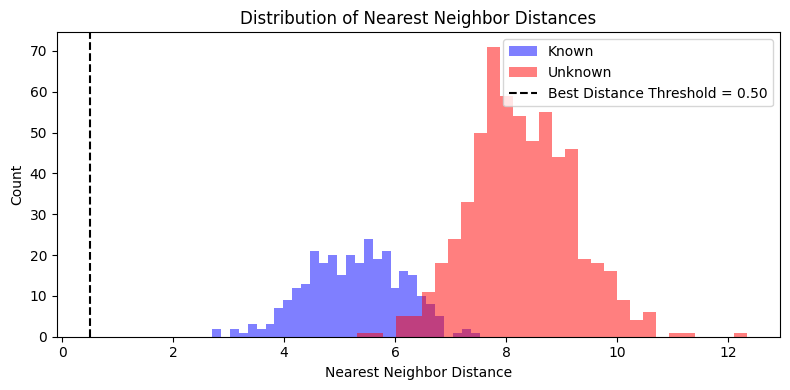

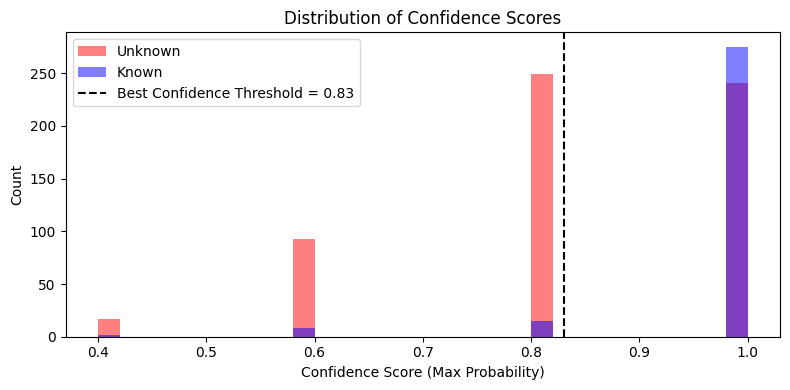

In [5]:

# ===================== Ultimate Unknown Detection Section =====================
# 1. Threshold sweep for confidence and distance
conf_thresholds = np.linspace(0.3, 0.9, 25)
dist_thresholds = np.linspace(0.5, 10, 100)

# KNN distances for unknowns
knn_dists, _ = knn_euc.kneighbors(unknown_embeddings_euc)

# KNN distances for known test set (for threshold calibration)
knn_dists_known, _ = knn_euc.kneighbors(test_embeddings_euc)

# Helper: detection rate for a threshold
results = {}
for t in conf_thresholds:
    unknown_flagged = (unknown_confidences < t).astype(int)
    rate = unknown_flagged.mean()
    results[f'conf_{t:.2f}'] = rate
best_conf_t = max(results, key=results.get)
print(f"[Ultimate] Best confidence threshold: {best_conf_t.split('_')[1]}, Detection Rate: {results[best_conf_t]:.2%}")

# Distance-based threshold
results_dist = {}
for t in dist_thresholds:
    unknown_flagged = (knn_dists[:,0] > t).astype(int)
    rate = unknown_flagged.mean()
    results_dist[f'dist_{t:.2f}'] = rate
best_dist_t = max(results_dist, key=results_dist.get)
print(f"[Ultimate] Best distance threshold: {best_dist_t.split('_')[1]}, Detection Rate: {results_dist[best_dist_t]:.2%}")

# Plot detection rate vs threshold
plt.figure(figsize=(6,4))
plt.plot(conf_thresholds, [results[f'conf_{t:.2f}'] for t in conf_thresholds], label='Confidence')
plt.axhline(0.9, color='r', linestyle='--', label='90% target')
plt.xlabel('Confidence Threshold')
plt.ylabel('Unknown Detection Rate')
plt.title('Unknown Detection Rate vs Confidence Threshold')
plt.legend()
plt.tight_layout()
plt.savefig('results/unknown_detection_rate_vs_confidence_threshold_efficientnet.png', dpi=300)
plt.close()

plt.figure(figsize=(8,4))
plt.plot(dist_thresholds, [results_dist[f'dist_{t:.2f}'] for t in dist_thresholds], label='Distance')
plt.axhline(0.9, color='r', linestyle='--', label='90% target')
plt.xlabel('Distance Threshold')
plt.ylabel('Unknown Detection Rate')
plt.title('Unknown Detection Rate vs Distance Threshold')
plt.legend()
plt.tight_layout()
plt.savefig('results/unknown_detection_rate_vs_distance_threshold_efficientnet.png', dpi=300)
plt.close()

# 2. One-Class SVM (fit on known train embeddings)
ocsvm = OneClassSVM(gamma='auto').fit(train_embeddings_euc)
unknown_ocsvm_pred = ocsvm.predict(unknown_embeddings_euc) #unknown == -1
unknown_ocsvm_flagged = (unknown_ocsvm_pred == -1).astype(int)
ocsvm_rate = unknown_ocsvm_flagged.mean()
print(f"[Ultimate] One-Class SVM Unknown Detection Rate: {ocsvm_rate:.2%}")

# 3. Isolation Forest (fit on known train embeddings)
iso_forest = IsolationForest(contamination=0.1, random_state=42).fit(train_embeddings_euc)
unknown_iso_pred = iso_forest.predict(unknown_embeddings_euc)
unknown_iso_flagged = (unknown_iso_pred == -1).astype(int)
iso_rate = unknown_iso_flagged.mean()
print(f"[Ultimate] Isolation Forest Unknown Detection Rate: {iso_rate:.2%}")

# 4. t-SNE visualization
try:
    tsne = TSNE(n_components=2, random_state=42)
    emb_vis = np.concatenate([test_embeddings_euc, unknown_embeddings_euc], axis=0)
    tsne_emb = tsne.fit_transform(emb_vis)
    plt.figure(figsize=(8,6))
    plt.scatter(tsne_emb[:len(test_embeddings_euc),0], tsne_emb[:len(test_embeddings_euc),1], c='b', label='Known Test', alpha=0.5)
    plt.scatter(tsne_emb[len(test_embeddings_euc):,0], tsne_emb[len(test_embeddings_euc):,1], c='r', label='Unknown', alpha=0.5)
    plt.legend()
    plt.title('t-SNE of Embeddings: Known vs Unknown')
    plt.tight_layout()
    plt.savefig('results/tsne_known_vs_unknown_efficientnet.png', dpi=300)
    plt.close()
except Exception as e:
    print(f"t-SNE visualization failed: {e}")

# 5. Ensemble Voting (majority of 3: confidence, distance, OCSVM, Isolation Forest)
# Use best thresholds found above
conf_t = float(best_conf_t.split('_')[1])
dist_t = float(best_dist_t.split('_')[1])
ensemble_votes = np.stack([
    (unknown_confidences < conf_t).astype(int),
    (knn_dists[:,0] > dist_t).astype(int),
    unknown_ocsvm_flagged,
    unknown_iso_flagged
], axis=1)
ensemble_flagged = (ensemble_votes.sum(axis=1) >= 2).astype(int)
ensemble_rate = ensemble_flagged.mean()
print(f"[Ultimate] Ensemble Unknown Detection Rate (>=2/4 votes): {ensemble_rate:.2%}")

# Save ensemble results plot
plt.figure(figsize=(6,3))
plt.bar(['Confidence', 'Distance', 'OCSVM', 'IsoForest', 'Ensemble'],
        [results[best_conf_t], results_dist[best_dist_t], ocsvm_rate, iso_rate, ensemble_rate])
plt.ylim(0,1)
plt.ylabel('Unknown Detection Rate')
plt.title('Unknown Detection Rate by Method')
plt.tight_layout()
plt.savefig('results/unknown_detection_rate_by_method_efficientnet.png', dpi=300)
plt.close()

# Print summary
print("\n[Ultimate] Unknown Detection Summary:")
print(f"Best Confidence Threshold: {conf_t:.2f}, Detection Rate: {results[best_conf_t]:.2%}")
print(f"Best Distance Threshold: {dist_t:.2f}, Detection Rate: {results_dist[best_dist_t]:.2%}")
print(f"One-Class SVM Detection Rate: {ocsvm_rate:.2%}")
print(f"Isolation Forest Detection Rate: {iso_rate:.2%}")
print(f"Ensemble (>=2/4 votes) Detection Rate: {ensemble_rate:.2%}")
if ensemble_rate >= 0.9:
    print("🎉 Ultimate goal achieved: >=90% unknown detection rate!")
else:
    print("⚠️  Ultimate goal not yet reached. Try tuning, more data, or better embeddings.")
# ===================== End Ultimate Unknown Detection Section =====================

# ===================== Plot Histograms with Best Results =====================

# 1. Histogram of nearest neighbor distances (known vs unknown)
plt.figure(figsize=(8, 4))
plt.hist(knn_dists_known[:, 0], bins=30, alpha=0.5, label='Known', color='blue')
plt.hist(knn_dists[:, 0], bins=30, alpha=0.5, label='Unknown', color='red')
plt.axvline(dist_t, color='k', linestyle='--', label=f'Best Distance Threshold = {dist_t:.2f}')
plt.xlabel('Nearest Neighbor Distance')
plt.ylabel('Count')
plt.title('Distribution of Nearest Neighbor Distances')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Histogram of confidence scores (known vs unknown)
plt.figure(figsize=(8, 4))
plt.hist(unknown_confidences, bins=30, alpha=0.5, label='Unknown', color='red')
# For knowns, get confidence scores (max probability) from KNN on test set
if hasattr(knn_euc, 'predict_proba'):
    known_confidences = np.max(knn_euc.predict_proba(test_embeddings_euc), axis=1)
else:
    dists_known, _ = knn_euc.kneighbors(test_embeddings_euc)
    known_confidences = 1 - dists_known[:, 0] / np.max(dists_known)
plt.hist(known_confidences, bins=30, alpha=0.5, label='Known', color='blue')
plt.axvline(conf_t, color='k', linestyle='--', label=f'Best Confidence Threshold = {conf_t:.2f}')
plt.xlabel('Confidence Score (Max Probability)')
plt.ylabel('Count')
plt.title('Distribution of Confidence Scores')
plt.legend()
plt.tight_layout()
plt.show()
# ===================== End Plot Histograms with Best Results ===================== 